# Data Mining Assignment
## Apache Spark Data Lake Preprocessing

**Dataset:** sales.csv  
**Environment:** Google Colab + PySpark

### Objective
Create a simple Data Lake using Bronze and Silver layers, inspect the raw sales data using Apache Spark, perform basic preprocessing, and save the processed dataset in the Silver layer.

In [6]:
!pip install -q pyspark

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DateType

import os
import shutil

## 1. Create Spark Session

A SparkSession is the entry point for working with DataFrames and performing Spark operations.

In [8]:
spark = SparkSession.builder \
    .appName("SalesDataLakePreprocessing") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 4.0.4


## 2. Create Data Lake Structure

The Data Lake contains two layers:

- **Bronze:** Raw sales data, kept unchanged.
- **Silver:** Preprocessed sales data.


In [9]:

os.makedirs("data_lake/bronze", exist_ok=True)
os.makedirs("data_lake/silver/preprocessed_sales", exist_ok=True)

print("Data Lake directories created successfully.")

Data Lake directories created successfully.


In [10]:
bronze_file = "data_lake/bronze/sales_silver.csv"

bronze_df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv(bronze_file)

bronze_df.show(5)

+--------+-----------+------------------+--------------------+---------+--------+----------+----------------+----------------+----------+-----------+----------+------------+
|order_id|customer_id|     customer_name|             product| category|quantity|unit_price|discount_percent|  payment_method|      city|      state|order_date|order_status|
+--------+-----------+------------------+--------------------+---------+--------+----------+----------------+----------------+----------+-----------+----------+------------+
|  100331|      C0005|      Sakshi Joshi|            Football|   Sports|       2|       670|              30|     Credit Card| Bengaluru|  Karnataka|2025-06-06|   Cancelled|
|  100333|      C0263|Siddharth Kulkarni|    Programming Book|    Books|       4|       670|               0|     Net Banking|      Pune|Maharashtra|2025-05-08|   Delivered|
|  100506|      C0228|     Diya Tripathi|Competitive Exam ...|    Books|       6|       610|              12|             UPI|Coim

In [11]:
bronze_df.printSchema()


root
 |-- order_id: integer (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- discount_percent: integer (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- order_status: string (nullable = true)



In [12]:
initial_count = bronze_df.count()

print("Total records in Bronze:", initial_count)

Total records in Bronze: 990


## 3. Printing all Columns

In [13]:
print("Columns:")
for column in bronze_df.columns:
    print("-", column)

Columns:
- order_id
- customer_id
- customer_name
- product
- category
- quantity
- unit_price
- discount_percent
- payment_method
- city
- state
- order_date
- order_status


In [14]:
for column, dtype in bronze_df.dtypes:
    print(f"{column}: {dtype}")

order_id: int
customer_id: string
customer_name: string
product: string
category: string
quantity: int
unit_price: int
discount_percent: int
payment_method: string
city: string
state: string
order_date: string
order_status: string


## 4. Data Quality Checks

### 4.1 Exact Duplicate Rows

Exact duplicate rows are records where all column values are identical.

In [15]:
distinct_count = bronze_df.dropDuplicates().count()
duplicate_count = initial_count - distinct_count

print("Total records:", initial_count)
print("Distinct records:", distinct_count)
print("Exact duplicate rows:", duplicate_count)

Total records: 990
Distinct records: 990
Exact duplicate rows: 0


In [16]:
duplicate_rows = bronze_df.groupBy(bronze_df.columns) \
    .count() \
    .filter(F.col("count") > 1)

duplicate_rows.show(truncate=False)

+--------+-----------+-------------+-------+--------+--------+----------+----------------+--------------+----+-----+----------+------------+-----+
|order_id|customer_id|customer_name|product|category|quantity|unit_price|discount_percent|payment_method|city|state|order_date|order_status|count|
+--------+-----------+-------------+-------+--------+--------+----------+----------------+--------------+----+-----+----------+------------+-----+
+--------+-----------+-------------+-------+--------+--------+----------+----------------+--------------+----+-----+----------+------------+-----+



### 4.2 Missing Values

Check the number of null values in every column.

In [17]:
null_counts = bronze_df.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in bronze_df.columns
])

null_counts.show()

+--------+-----------+-------------+-------+--------+--------+----------+----------------+--------------+----+-----+----------+------------+
|order_id|customer_id|customer_name|product|category|quantity|unit_price|discount_percent|payment_method|city|state|order_date|order_status|
+--------+-----------+-------------+-------+--------+--------+----------+----------------+--------------+----+-----+----------+------------+
|       0|          0|            0|      0|       0|      12|         8|               8|             0|   0|    0|         6|           0|
+--------+-----------+-------------+-------+--------+--------+----------+----------------+--------------+----+-----+----------+------------+



In [18]:
text_columns = [
    field.name
    for field in bronze_df.schema.fields
    if field.dataType.simpleString() == "string"
]

empty_counts = bronze_df.select([
    F.sum(
        F.when(
            F.col(c).isNull() | (F.trim(F.col(c)) == ""),
            1
        ).otherwise(0)
    ).alias(c)
    for c in text_columns
])

empty_counts.show()

+-----------+-------------+-------+--------+--------------+----+-----+----------+------------+
|customer_id|customer_name|product|category|payment_method|city|state|order_date|order_status|
+-----------+-------------+-------+--------+--------------+----+-----+----------+------------+
|          0|            0|      0|       0|             0|   0|    0|         6|           0|
+-----------+-------------+-------+--------+--------------+----+-----+----------+------------+



In [19]:
invalid_qty = bronze_df.filter(F.col("quantity") <= 0)
print(f"Invalid Quantity Records: {invalid_qty.count()}")

invalid_price = bronze_df.filter(F.col("unit_price") <= 0)
print(f"Invalid Unit Price Records: {invalid_price.count()}")

invalid_disc = bronze_df.filter((F.col("discount_percent") < 0) | (F.col("discount_percent") > 100))
print(f"Invalid Discount Records: {invalid_disc.count()}")

parsed_dates_df = bronze_df.withColumn("parsed_date", F.try_to_timestamp(F.col("order_date"), F.lit("yyyy-MM-dd")).cast("date"))
invalid_dates = parsed_dates_df.filter(F.col("parsed_date").isNull())
print(f"Invalid Order Date Records: {invalid_dates.count()}")

Invalid Quantity Records: 0
Invalid Unit Price Records: 0
Invalid Discount Records: 0
Invalid Order Date Records: 6


In [20]:
date_check_df = bronze_df.withColumn(
    "parsed_date",
    F.try_to_timestamp(F.col("order_date"), F.lit("yyyy-MM-dd")).cast("date")
)

invalid_dates = date_check_df.filter(
    F.col("parsed_date").isNull()
)

print("Invalid date records:", invalid_dates.count())

invalid_dates.select("order_id", "order_date").show(truncate=False)

Invalid date records: 6
+--------+----------+
|order_id|order_date|
+--------+----------+
|100097  |NULL      |
|100637  |NULL      |
|100969  |NULL      |
|100448  |NULL      |
|100634  |NULL      |
|100358  |NULL      |
+--------+----------+



# 5. Bronze to Silver Preprocessing

The following preprocessing operations will be performed:

1. Remove exact duplicate rows.
2. Handle missing values.
3. Trim extra spaces from text fields.
4. Standardize obvious capitalization inconsistencies.
5. Validate quantity, unit price, and discount percentage.
6. Convert valid dates into one consistent format.
7. Preserve useful records wherever possible.

In [21]:
silver_df = bronze_df.dropDuplicates()

print("Rows before duplicate removal:", bronze_df.count())
print("Rows after duplicate removal:", silver_df.count())

Rows before duplicate removal: 990
Rows after duplicate removal: 990


In [22]:
for column in text_columns:
    silver_df = silver_df.withColumn(
        column,
        F.trim(F.col(column))
    )

In [23]:
silver_df = silver_df.withColumn(
    "category",
    F.initcap(F.col("category"))
)

In [24]:
silver_df = silver_df.withColumn(
    "city",
    F.initcap(F.col("city"))
)

In [25]:
# Preserving useful records where possible
# Handle Missing Customer Names
silver_df = silver_df.withColumn(
    "customer_name",
    F.when(
        F.col("customer_name").isNull() |
        (F.trim(F.col("customer_name")) == ""),
        F.lit("Unknown")
    ).otherwise(F.col("customer_name"))
)



In [26]:
#Handle Missing Payment Method

silver_df = silver_df.withColumn(
    "payment_method",
    F.when(
        F.col("payment_method").isNull() |
        (F.trim(F.col("payment_method")) == ""),
        F.lit("Unknown")
    ).otherwise(F.col("payment_method"))
)



In [27]:
#Handle Missing City

silver_df = silver_df.withColumn(
    "city",
    F.when(
        F.col("city").isNull() |
        (F.trim(F.col("city")) == ""),
        F.lit("Unknown")
    ).otherwise(F.col("city"))
)



In [28]:
# Handle Invalid Quantity
silver_df = silver_df.withColumn(
    "quantity",
    F.when(
        F.col("quantity") > 0,
        F.col("quantity")
    ).otherwise(F.lit(None))
)

In [29]:
# Handle Invalid Unit Price

silver_df = silver_df.withColumn(
    "unit_price",
    F.when(
        F.col("unit_price") > 0,
        F.col("unit_price")
    ).otherwise(F.lit(None))
)

In [30]:
# Handle Invalid Discount

silver_df = silver_df.withColumn(
    "discount_percent",
    F.when(
        (F.col("discount_percent") >= 0) &
        (F.col("discount_percent") <= 100),
        F.col("discount_percent")
    ).otherwise(F.lit(None))
)

In [31]:
# Convert order_date safely to a DateType.
# Invalid dates like '31/02/2026' or 'not-a-date' will safely become NULL.
silver_df = silver_df.withColumn(
    "order_date",
    F.try_to_timestamp(F.col("order_date"), F.lit("yyyy-MM-dd")).cast("date")
)

In [32]:
silver_df.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- discount_percent: integer (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- order_status: string (nullable = true)



In [33]:
final_count = silver_df.count()

print("Row count before preprocessing:", initial_count)
print("Row count after preprocessing :", final_count)
print("Rows removed                  :", initial_count - final_count)

Row count before preprocessing: 990
Row count after preprocessing : 990
Rows removed                  : 0


In [34]:
silver_df.show(10, truncate=False)

+--------+-----------+------------------+----------------------+---------+--------+----------+----------------+----------------+----------+-----------+----------+------------+
|order_id|customer_id|customer_name     |product               |category |quantity|unit_price|discount_percent|payment_method  |city      |state      |order_date|order_status|
+--------+-----------+------------------+----------------------+---------+--------+----------+----------------+----------------+----------+-----------+----------+------------+
|100892  |C0291      |Varun Pillai      |Coffee 500g           |Grocery  |2       |780       |15              |Net Banking     |Unknown   |Karnataka  |2026-04-17|Shipped     |
|100331  |C0005      |Sakshi Joshi      |Football              |Sports   |2       |670       |30              |Credit Card     |Bengaluru |Karnataka  |2025-06-06|Cancelled   |
|100333  |C0263      |Siddharth Kulkarni|Programming Book      |Books    |4       |670       |0               |Net Banki

In [35]:
silver_output_dir = "data_lake/silver/preprocessed_sales"

# Remove previous output directory if it exists
if os.path.exists(silver_output_dir):
    shutil.rmtree(silver_output_dir)

# Write directly to CSV — Spark automatically formats DateType columns as yyyy-MM-dd
silver_df.coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", True) \
    .csv(silver_output_dir)

print("Silver data written successfully.")

Silver data written successfully.


In [36]:
import os
import shutil

silver_output_dir = "data_lake/silver/preprocessed_sales"
final_silver_file = "data_lake/silver/sales_silver.csv"

# Locate the Spark part file
part_file = [os.path.join(silver_output_dir, f) for f in os.listdir(silver_output_dir) if f.startswith("part-") and f.endswith(".csv")][0]

# Copy and rename it to sales_silver.csv
shutil.copy2(part_file, final_silver_file)

print(f"✓ Final file ready for submission: {final_silver_file}")

✓ Final file ready for submission: data_lake/silver/sales_silver.csv


## 6. Verification

The Silver dataset is read back using Spark to verify that the saved output can be loaded successfully.

In [37]:
silver_read_df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv(final_silver_file)

In [38]:
silver_read_df.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- discount_percent: integer (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- order_status: string (nullable = true)



In [39]:
silver_read_df.show(10, truncate=False)

+--------+-----------+------------------+----------------------+---------+--------+----------+----------------+----------------+----------+-----------+----------+------------+
|order_id|customer_id|customer_name     |product               |category |quantity|unit_price|discount_percent|payment_method  |city      |state      |order_date|order_status|
+--------+-----------+------------------+----------------------+---------+--------+----------+----------------+----------------+----------+-----------+----------+------------+
|100892  |C0291      |Varun Pillai      |Coffee 500g           |Grocery  |2       |780       |15              |Net Banking     |Unknown   |Karnataka  |2026-04-17|Shipped     |
|100331  |C0005      |Sakshi Joshi      |Football              |Sports   |2       |670       |30              |Credit Card     |Bengaluru |Karnataka  |2025-06-06|Cancelled   |
|100333  |C0263      |Siddharth Kulkarni|Programming Book      |Books    |4       |670       |0               |Net Banki

In [40]:
silver_read_count = silver_read_df.count()

print("Silver records:", silver_read_count)

Silver records: 990


In [41]:
remaining_duplicates = (
    silver_read_count -
    silver_read_df.dropDuplicates().count()
)

print("Remaining exact duplicates:", remaining_duplicates)

Remaining exact duplicates: 0


In [42]:
invalid_quantity_after = silver_read_df.filter(
    F.col("quantity") <= 0
).count()

invalid_price_after = silver_read_df.filter(
    F.col("unit_price") <= 0
).count()

invalid_discount_after = silver_read_df.filter(
    (F.col("discount_percent") < 0) |
    (F.col("discount_percent") > 100)
).count()

print("Invalid quantities remaining:", invalid_quantity_after)
print("Invalid prices remaining:", invalid_price_after)
print("Invalid discounts remaining:", invalid_discount_after)

Invalid quantities remaining: 0
Invalid prices remaining: 0
Invalid discounts remaining: 0


## 5. Preprocessing Summary

The following preprocessing operations were performed:

1. Loaded the raw `sales.csv` using Apache Spark.
2. Kept the original dataset unchanged in the Bronze layer.
3. Identified and removed exact duplicate rows.
4. Identified missing values in the dataset.
5. Replaced missing customer names, payment methods, and cities with `Unknown` to preserve useful records.
6. Trimmed leading and trailing spaces from text fields.
7. Standardized capitalization for category and city values.
8. Validated quantity and converted non-positive values to null.
9. Validated unit price and converted non-positive values to null.
10. Validated discount percentages and converted values outside 0–100 to null.
11. Converted valid order dates to a consistent date format.
12. Converted invalid dates to null while preserving the corresponding sales records.
13. Saved the processed dataset in the Silver layer.
14. Read the Silver dataset back using Spark and verified the resulting data.

## 6 Exploratory Data Analysis (EDA) on Silver Data

Now that the data is cleaned and stored in the Silver layer, we can perform basic analytics using Spark DataFrames, Spark SQL, and Pandas/Matplotlib for visualization.

In [43]:
print("--- Statistical Summary of Cleaned Numerical Columns ---")
silver_read_df.select("quantity", "unit_price", "discount_percent") \
    .summary("count", "mean", "min", "25%", "50%", "75%", "max") \
    .show()

--- Statistical Summary of Cleaned Numerical Columns ---
+-------+-----------------+-----------------+------------------+
|summary|         quantity|       unit_price|  discount_percent|
+-------+-----------------+-----------------+------------------+
|  count|              978|              982|               982|
|   mean|5.420245398773006|5772.331975560081|19.593686354378818|
|    min|                1|              190|                 0|
|    25%|                3|              740|                10|
|    50%|                5|             1850|                20|
|    75%|                8|             4900|                30|
|    max|               10|            81010|                40|
+-------+-----------------+-----------------+------------------+



In [44]:
# Register the Silver DataFrame as a temporary SQL view
silver_read_df.createOrReplaceTempView("silver_sales")

print("--- Top 5 Cities by Order Count ---")
spark.sql("""
    SELECT city, COUNT(order_id) as total_orders
    FROM silver_sales
    WHERE city != 'Unknown'
    GROUP BY city
    ORDER BY total_orders DESC
    LIMIT 5
""").show()

--- Top 5 Cities by Order Count ---
+----------+------------+
|      city|total_orders|
+----------+------------+
|    Mumbai|         105|
|Vijayawada|         104|
| Hyderabad|          97|
| Bengaluru|          90|
|   Lucknow|          89|
+----------+------------+



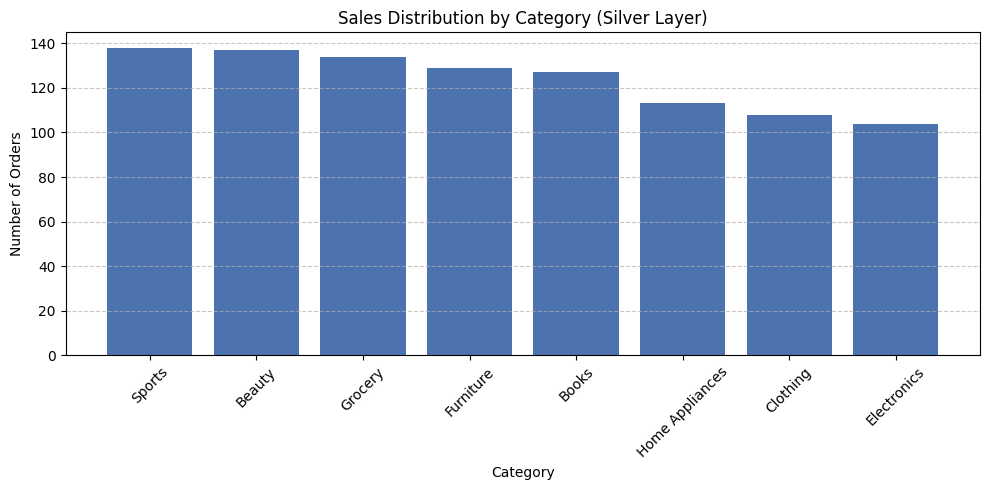

In [45]:
import matplotlib.pyplot as plt

# Aggregate category counts using Spark
category_distribution = spark.sql("""
    SELECT category, COUNT(*) as count
    FROM silver_sales
    GROUP BY category
    ORDER BY count DESC
""").toPandas() # Convert to Pandas for plotting

# Plot the results
plt.figure(figsize=(10, 5))
plt.bar(category_distribution['category'], category_distribution['count'], color='#4C72B0')
plt.title('Sales Distribution by Category (Silver Layer)')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [46]:
spark.stop()